# ShotGuide CLIP 임베딩 기반 분류기 학습

이 노트북은 frozen CLIP ViT-B/32 이미지 임베딩을 추출하고, 그 위에 작은 multi-task head를 학습합니다.

- `outputs/baseline/dataset_index_with_splits.csv`의 기존 video-level split을 사용합니다.
- 라벨링 이미지마다 512차원 CLIP 임베딩을 하나씩 추출합니다.
- 추출한 임베딩을 저장해 다음 학습에서 재사용합니다.
- `shot_type`과 `has_text`를 동시에 예측하는 head를 학습합니다.



In [3]:
# 학습과 평가에 필요한 라이브러리를 불러오고 재현성을 위한 seed를 고정합니다.
from pathlib import Path
from collections import Counter
import json
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from torch.utils.data import DataLoader, Dataset, TensorDataset
from tqdm.auto import tqdm
import open_clip

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.benchmark = True

# 프로젝트 루트와 입력 split CSV, 출력 폴더를 설정합니다.
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
SPLIT_CSV = ROOT / 'outputs/baseline' / 'dataset_index_with_splits.csv'
OUTPUT_DIR = ROOT / 'outputs/clip_embeddings'
CHECKPOINT_DIR = ROOT / 'checkpoints'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# GPU가 있으면 CUDA를 사용하고, 없으면 CPU로 실행합니다.
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE



device(type='cpu')

## 1. 고정 Split 불러오기

이전 ResNet baseline과 공정하게 비교하기 위해 같은 train/val/test split을 재사용합니다.



In [4]:
# 라벨 데이터 인덱스를 읽고 train/val/test split이 올바른지 확인합니다.
df = pd.read_csv(SPLIT_CSV)
df['has_text'] = df['has_text'].astype(int)

valid_splits = {'train', 'val', 'test'}
assert set(df['split'].unique()) == valid_splits, df['split'].unique()

# 같은 video_id가 여러 split에 섞이지 않았는지 확인합니다.
leaks = [video_id for video_id, g in df.groupby('video_id') if g['split'].nunique() > 1]
print('rows:', len(df))
print('videos:', df['video_id'].nunique())
print('group leakage count:', len(leaks))
assert len(leaks) == 0

display(pd.crosstab(df['joint_label'], df['split']))
display(df.head())



rows: 1188
videos: 129
group leakage count: 0


split,test,train,val
joint_label,,,
close-up_notext,4,24,1
close-up_text,26,76,16
medium_notext,6,45,23
medium_text,79,189,63
object_notext,4,30,5
object_text,58,148,51
space_notext,5,19,4
space_text,22,60,14
wide_notext,23,48,2


,filepath,filename,video_id,original_class,shot_type,has_text,joint_label,split
0,C:\Temp\deep\labeled_dataset\close-up_notext\0...,0013_cut_006.jpg,13,close-up_notext,close-up,0,close-up_notext,train
1,C:\Temp\deep\labeled_dataset\close-up_notext\0...,0013_cut_012.jpg,13,close-up_notext,close-up,0,close-up_notext,train
2,C:\Temp\deep\labeled_dataset\close-up_notext\0...,0013_cut_017.jpg,13,close-up_notext,close-up,0,close-up_notext,train
3,C:\Temp\deep\labeled_dataset\close-up_notext\0...,0015_cut_001.jpg,15,close-up_notext,close-up,0,close-up_notext,train
4,C:\Temp\deep\labeled_dataset\close-up_notext\0...,0024_cut_012.jpg,24,close-up_notext,close-up,0,close-up_notext,train


## 2. Frozen CLIP ViT-B/32 불러오기

처음 실행할 때는 OpenAI CLIP pretrained weight를 다운로드할 수 있습니다.



In [5]:
# CLIP ViT-B/32 backbone을 불러오고 backbone 가중치는 학습하지 않도록 고정합니다.
MODEL_NAME = 'ViT-B-32'
PRETRAINED = 'openai'

model, _, preprocess = open_clip.create_model_and_transforms(MODEL_NAME, pretrained=PRETRAINED, device=DEVICE)
model.eval()

# 아래 head만 학습할 것이므로 CLIP 파라미터는 freeze합니다.
for param in model.parameters():
    param.requires_grad = False

print('model:', MODEL_NAME, PRETRAINED)
print('embedding dim:', model.visual.output_dim)



c:\Users\eunpa\anaconda3\envs\sy\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\eunpa\.cache\huggingface\hub\models--timm--vit_base_patch32_clip_224.openai. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
c:\Users\eunpa\anaconda3\envs\sy\Lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGEL

model: ViT-B-32 openai
embedding dim: 512


## 3. CLIP 임베딩 추출 및 저장



In [6]:
class ImagePathDataset(Dataset):
    # CSV의 이미지 경로를 읽어 CLIP 전처리를 적용하는 Dataset입니다.
    def __init__(self, frame: pd.DataFrame, transform):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        path = self.frame.loc[idx, 'filepath']
        image = Image.open(path).convert('RGB')
        return self.transform(image), idx

# 임베딩 캐시 파일 경로입니다. 이미 존재하면 재계산하지 않고 불러옵니다.
EMBEDDING_NPZ = OUTPUT_DIR / 'clip_vit_b32_openai_embeddings.npz'
EMBEDDING_META_CSV = OUTPUT_DIR / 'clip_embedding_metadata.csv'

# 캐시가 있으면 빠르게 로드하고, 없으면 CLIP으로 새로 추출합니다.
if EMBEDDING_NPZ.exists() and EMBEDDING_META_CSV.exists():
    print('Loading cached embeddings:', EMBEDDING_NPZ)
    cached = np.load(EMBEDDING_NPZ)
    embeddings = cached['embeddings']
else:
    loader = DataLoader(ImagePathDataset(df, preprocess), batch_size=64, shuffle=False, num_workers=0)
    embedding_chunks = []
    order = []

    with torch.no_grad():
        for images, indices in tqdm(loader):
            images = images.to(DEVICE)
            features = model.encode_image(images)
            features = features / features.norm(dim=-1, keepdim=True)
            embedding_chunks.append(features.cpu().float().numpy())
            order.extend(indices.numpy().tolist())

    embeddings = np.concatenate(embedding_chunks, axis=0).astype('float32')
    order = np.array(order)
    assert np.all(order == np.arange(len(df)))

        # 다음 실행에서 재사용할 수 있도록 임베딩과 라벨 메타데이터를 저장합니다.
    np.savez_compressed(
        EMBEDDING_NPZ,
        embeddings=embeddings,
        has_text=df['has_text'].to_numpy(dtype=np.int64),
        split=df['split'].to_numpy(),
        shot_type=df['shot_type'].to_numpy(),
        filepath=df['filepath'].to_numpy(),
    )
    df.assign(embedding_index=np.arange(len(df))).to_csv(EMBEDDING_META_CSV, index=False, encoding='utf-8-sig')

print('embedding shape:', embeddings.shape)
print('saved:', EMBEDDING_NPZ)



Loading cached embeddings: c:\Temp\shot-classification\outputs_clip_embeddings\clip_vit_b32_openai_embeddings.npz
embedding shape: (1188, 512)
saved: c:\Temp\shot-classification\outputs_clip_embeddings\clip_vit_b32_openai_embeddings.npz


## 4. Frozen 임베딩 위에 Multi-task Head 학습



In [7]:
# shot type 문자열 라벨을 정수 index로 변환하고 split별 TensorDataset을 준비합니다.
SHOT_TYPES = ['close-up', 'medium', 'object', 'space', 'wide']
shot_to_idx = {name: i for i, name in enumerate(SHOT_TYPES)}
idx_to_shot = {i: name for name, i in shot_to_idx.items()}

shot_labels = df['shot_type'].map(shot_to_idx).to_numpy(dtype=np.int64)
text_labels = df['has_text'].to_numpy(dtype=np.int64)

def split_arrays(split_name):
    # 지정한 split에 해당하는 임베딩과 라벨만 분리합니다.
    mask = df['split'].to_numpy() == split_name
    x = torch.tensor(embeddings[mask], dtype=torch.float32)
    y_shot = torch.tensor(shot_labels[mask], dtype=torch.long)
    y_text = torch.tensor(text_labels[mask], dtype=torch.long)
    return x, y_shot, y_text, mask

x_train, y_shot_train, y_text_train, train_mask = split_arrays('train')
x_val, y_shot_val, y_text_val, val_mask = split_arrays('val')
x_test, y_shot_test, y_text_test, test_mask = split_arrays('test')

# 학습/검증/테스트용 DataLoader를 만듭니다.
train_loader = DataLoader(TensorDataset(x_train, y_shot_train, y_text_train), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(x_val, y_shot_val, y_text_val), batch_size=256, shuffle=False)
test_loader = DataLoader(TensorDataset(x_test, y_shot_test, y_text_test), batch_size=256, shuffle=False)

x_train.shape, x_val.shape, x_test.shape



(torch.Size([721, 512]), torch.Size([208, 512]), torch.Size([259, 512]))

In [8]:
class ClipEmbeddingMultiTaskHead(nn.Module):
    # CLIP 임베딩을 입력받아 shot type과 text 여부를 동시에 예측하는 head입니다.
    def __init__(self, embedding_dim=512, hidden_dim=256, num_shot_classes=5, dropout=0.20):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.shot_head = nn.Linear(hidden_dim, num_shot_classes)
        self.text_head = nn.Linear(hidden_dim, 2)

    def forward(self, x):
        z = self.shared(x)
        return self.shot_head(z), self.text_head(z)

def make_class_weights(labels, num_classes):
    # 라벨 불균형을 완화하기 위해 class weight를 계산합니다.
    counts = Counter(labels.tolist())
    total = sum(counts.values())
    return torch.tensor([total / (num_classes * max(counts.get(i, 0), 1)) for i in range(num_classes)], dtype=torch.float32)

# head, loss, optimizer를 정의합니다.
head = ClipEmbeddingMultiTaskHead(embedding_dim=embeddings.shape[1], hidden_dim=256).to(DEVICE)
shot_criterion = nn.CrossEntropyLoss(weight=make_class_weights(y_shot_train, len(SHOT_TYPES)).to(DEVICE))
text_criterion = nn.CrossEntropyLoss(weight=make_class_weights(y_text_train, 2).to(DEVICE))
optimizer = torch.optim.AdamW(head.parameters(), lr=1e-3, weight_decay=1e-3)

TEXT_LOSS_WEIGHT = 1.0
EPOCHS = 80
PATIENCE = 12

def evaluate(loader):
    # 주어진 loader에 대해 loss와 shot/text 성능 지표를 계산합니다.
    head.eval()
    total_loss = 0.0
    shot_true, shot_pred = [], []
    text_true, text_pred = [], []
    with torch.no_grad():
        for x, y_shot, y_text in loader:
            x = x.to(DEVICE)
            y_shot = y_shot.to(DEVICE)
            y_text = y_text.to(DEVICE)
            shot_logits, text_logits = head(x)
            loss = shot_criterion(shot_logits, y_shot) + TEXT_LOSS_WEIGHT * text_criterion(text_logits, y_text)
            total_loss += loss.item() * x.size(0)
            shot_true.extend(y_shot.cpu().numpy().tolist())
            shot_pred.extend(shot_logits.argmax(1).cpu().numpy().tolist())
            text_true.extend(y_text.cpu().numpy().tolist())
            text_pred.extend(text_logits.argmax(1).cpu().numpy().tolist())
    return {
        'loss': total_loss / len(loader.dataset),
        'shot_acc': accuracy_score(shot_true, shot_pred),
        'shot_macro_f1': f1_score(shot_true, shot_pred, average='macro', zero_division=0),
        'text_acc': accuracy_score(text_true, text_pred),
        'text_f1': f1_score(text_true, text_pred, average='binary', zero_division=0),
        'joint_acc': np.mean((np.array(shot_true) == np.array(shot_pred)) & (np.array(text_true) == np.array(text_pred))),
    }

def train_one_epoch(loader):
    # 한 epoch 동안 head를 학습합니다.
    head.train()
    for x, y_shot, y_text in loader:
        x = x.to(DEVICE)
        y_shot = y_shot.to(DEVICE)
        y_text = y_text.to(DEVICE)
        shot_logits, text_logits = head(x)
        loss = shot_criterion(shot_logits, y_shot) + TEXT_LOSS_WEIGHT * text_criterion(text_logits, y_text)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

# validation joint accuracy가 가장 좋은 head 상태를 저장합니다.
history = []
best_state = None
best_val_joint = -1.0
epochs_without_improvement = 0

# early stopping을 적용하며 학습을 반복합니다.
for epoch in range(1, EPOCHS + 1):
    train_one_epoch(train_loader)
    train_metrics = evaluate(train_loader)
    val_metrics = evaluate(val_loader)
    row = {'epoch': epoch, **{f'train_{k}': v for k, v in train_metrics.items()}, **{f'val_{k}': v for k, v in val_metrics.items()}}
    history.append(row)
    if epoch == 1 or epoch % 5 == 0:
        print(row)

    if val_metrics['joint_acc'] > best_val_joint:
        best_val_joint = val_metrics['joint_acc']
        best_state = {k: v.detach().cpu().clone() for k, v in head.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            print('Early stopping at epoch', epoch)
            break

head.load_state_dict(best_state)
history_df = pd.DataFrame(history)
history_df.to_csv(OUTPUT_DIR / 'clip_head_training_history.csv', index=False)

# 추론 파이프라인에서 사용할 PyTorch checkpoint를 저장합니다.
checkpoint_path = CHECKPOINT_DIR / 'clip_vit_b32_multitask_head.pt'
torch.save({
    'model_state_dict': best_state,
    'shot_to_idx': shot_to_idx,
    'idx_to_shot': idx_to_shot,
    'clip_model': MODEL_NAME,
    'clip_pretrained': PRETRAINED,
}, checkpoint_path)

print('best val joint acc:', best_val_joint)
print('saved:', checkpoint_path)
history_df.tail()



{'epoch': 1, 'train_loss': 2.219727792951502, 'train_shot_acc': 0.5686546463245492, 'train_shot_macro_f1': 0.4431324832965151, 'train_text_acc': 0.8391123439667129, 'train_text_f1': 0.8980667838312829, 'train_joint_acc': np.float64(0.492371705963939), 'val_loss': 2.22040057182312, 'val_shot_acc': 0.6153846153846154, 'val_shot_macro_f1': 0.3839185331576636, 'val_text_acc': 0.8173076923076923, 'val_text_f1': 0.8932584269662921, 'val_joint_acc': np.float64(0.4807692307692308)}
{'epoch': 5, 'train_loss': 1.565125901226197, 'train_shot_acc': 0.6837725381414702, 'train_shot_macro_f1': 0.6588639187339028, 'train_text_acc': 0.7808599167822469, 'train_text_f1': 0.8397565922920892, 'train_joint_acc': np.float64(0.536754507628294), 'val_loss': 1.739781379699707, 'val_shot_acc': 0.6153846153846154, 'val_shot_macro_f1': 0.5206890756302521, 'val_text_acc': 0.7788461538461539, 'val_text_f1': 0.85625, 'val_joint_acc': np.float64(0.49038461538461536)}
{'epoch': 10, 'train_loss': 1.0166777192140914, 'tr

,epoch,train_loss,train_shot_acc,train_shot_macro_f1,train_text_acc,train_text_f1,train_joint_acc,val_loss,val_shot_acc,val_shot_macro_f1,val_text_acc,val_text_f1,val_joint_acc
49,50,0.242217,0.972261,0.972561,0.957004,0.971323,0.932039,1.258550,0.716346,0.686353,0.826923,0.892216,0.596154
50,51,0.235309,0.975035,0.975911,0.962552,0.975161,0.938974,1.281865,0.721154,0.690850,0.836538,0.898810,0.605769
51,52,0.228809,0.977809,0.978293,0.961165,0.974217,0.941748,1.278055,0.716346,0.689351,0.826923,0.892216,0.591346
52,53,0.223539,0.979196,0.979490,0.961165,0.974217,0.943135,1.296711,0.701923,0.660208,0.831731,0.895522,0.581731
53,54,0.217612,0.973648,0.974103,0.961165,0.974217,0.936200,1.305936,0.716346,0.684810,0.836538,0.898204,0.605769


## 5. 테스트셋 평가



In [9]:
# 테스트셋에서 shot type과 text 여부를 예측하고 평가 지표를 계산합니다.
head.eval()
shot_true, shot_pred = [], []
text_true, text_pred = [], []
shot_conf, text_prob = [], []

with torch.no_grad():
    for x, y_shot, y_text in test_loader:
        x = x.to(DEVICE)
        shot_logits, text_logits = head(x)
        shot_p = torch.softmax(shot_logits, dim=1)
        text_p = torch.softmax(text_logits, dim=1)
        shot_true.extend(y_shot.numpy().tolist())
        text_true.extend(y_text.numpy().tolist())
        shot_pred.extend(shot_p.argmax(1).cpu().numpy().tolist())
        text_pred.extend(text_p.argmax(1).cpu().numpy().tolist())
        shot_conf.extend(shot_p.max(1).values.cpu().numpy().tolist())
        text_prob.extend(text_p[:, 1].cpu().numpy().tolist())

test_metrics = {
    'shot_acc': accuracy_score(shot_true, shot_pred),
    'shot_macro_f1': f1_score(shot_true, shot_pred, average='macro', zero_division=0),
    'text_acc': accuracy_score(text_true, text_pred),
    'text_f1': f1_score(text_true, text_pred, average='binary', zero_division=0),
    'joint_acc': np.mean((np.array(shot_true) == np.array(shot_pred)) & (np.array(text_true) == np.array(text_pred))),
}

# 평가 결과를 JSON으로 저장해 보고서나 비교 표에 재사용합니다.
with open(OUTPUT_DIR / 'clip_test_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(test_metrics, f, indent=2)

print(json.dumps(test_metrics, indent=2))
print('\nShot type report')
print(classification_report(shot_true, shot_pred, target_names=SHOT_TYPES, zero_division=0))
print('\nText report')
print(classification_report(text_true, text_pred, target_names=['notext', 'text'], zero_division=0))



{
  "shot_acc": 0.7992277992277992,
  "shot_macro_f1": 0.7642553651890452,
  "text_acc": 0.8378378378378378,
  "text_f1": 0.9004739336492891,
  "joint_acc": 0.6795366795366795
}

Shot type report
              precision    recall  f1-score   support

    close-up       0.73      0.53      0.62        30
      medium       0.80      0.88      0.84        85
      object       0.82      0.90      0.86        62
       space       0.69      0.74      0.71        27
        wide       0.87      0.73      0.79        55

    accuracy                           0.80       259
   macro avg       0.78      0.76      0.76       259
weighted avg       0.80      0.80      0.80       259


Text report
              precision    recall  f1-score   support

      notext       0.50      0.64      0.56        42
        text       0.93      0.88      0.90       217

    accuracy                           0.84       259
   macro avg       0.71      0.76      0.73       259
weighted avg       0.86      0

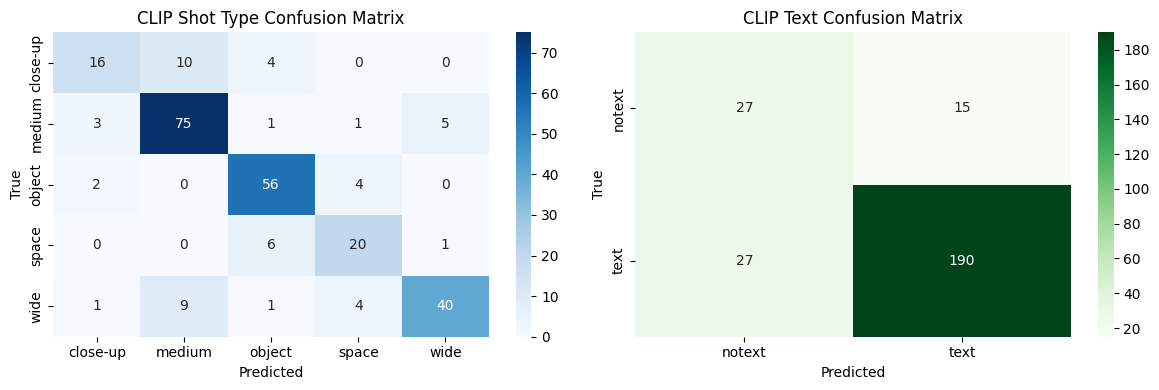

In [10]:
# shot type과 text 여부 각각의 confusion matrix를 시각화합니다.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

shot_cm = confusion_matrix(shot_true, shot_pred, labels=list(range(len(SHOT_TYPES))))
sns.heatmap(shot_cm, annot=True, fmt='d', cmap='Blues', xticklabels=SHOT_TYPES, yticklabels=SHOT_TYPES, ax=axes[0])
axes[0].set_title('CLIP Shot Type Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

text_cm = confusion_matrix(text_true, text_pred, labels=[0, 1])
sns.heatmap(text_cm, annot=True, fmt='d', cmap='Greens', xticklabels=['notext', 'text'], yticklabels=['notext', 'text'], ax=axes[1])
axes[1].set_title('CLIP Text Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
# 생성된 그림은 출력 폴더에 저장합니다.
plt.savefig(OUTPUT_DIR / 'clip_confusion_matrices.png', dpi=160)
plt.show()



In [11]:
# 테스트셋 각 샘플의 예측 결과와 정답 여부를 CSV로 저장합니다.
test_result_df = df[test_mask].copy().reset_index(drop=True)
test_result_df['pred_shot_type'] = [idx_to_shot[i] for i in shot_pred]
test_result_df['pred_has_text'] = text_pred
test_result_df['shot_confidence'] = shot_conf
test_result_df['text_probability'] = text_prob
test_result_df['shot_correct'] = test_result_df['shot_type'] == test_result_df['pred_shot_type']
test_result_df['text_correct'] = test_result_df['has_text'].astype(int) == test_result_df['pred_has_text']
test_result_df['joint_correct'] = test_result_df['shot_correct'] & test_result_df['text_correct']
test_result_df.to_csv(OUTPUT_DIR / 'clip_test_predictions.csv', index=False, encoding='utf-8-sig')

display(test_result_df[['filename', 'video_id', 'shot_type', 'pred_shot_type', 'has_text', 'pred_has_text', 'shot_confidence', 'text_probability', 'joint_correct']].head(20))



,filename,video_id,shot_type,pred_shot_type,has_text,pred_has_text,shot_confidence,text_probability,joint_correct
0,0037_cut_002.jpg,37,close-up,object,0,1,0.955114,0.661484,False
1,0048_cut_027.jpg,48,close-up,close-up,0,1,0.780338,0.529955,False
2,0114_cut_001.jpg,114,close-up,close-up,0,0,0.789447,0.091221,True
3,0114_cut_015.jpg,114,close-up,medium,0,0,0.512295,0.356656,False
4,0019_cut_002.jpg,19,close-up,medium,1,0,0.693057,0.095217,False
5,0025_cut_011.jpg,25,close-up,close-up,1,0,0.991931,0.052076,False
6,0048_cut_017.jpg,48,close-up,close-up,1,1,0.945007,0.982540,True
7,0048_cut_019.jpg,48,close-up,close-up,1,1,0.851196,0.986778,True
8,0048_cut_021.jpg,48,close-up,close-up,1,1,0.868997,0.732127,True
9,0048_cut_022.jpg,48,close-up,close-up,1,1,0.891812,0.977195,True


## 6. ResNet Baseline과 비교



In [12]:
# 기존 ResNet18 baseline 성능과 CLIP 임베딩 head 성능을 같은 표로 비교합니다.
resnet_metrics = {
    'shot_acc': 0.7104247104247104,
    'shot_macro_f1': 0.7071751112269045,
    'text_acc': 0.6602316602316602,
    'text_f1': 0.7621621621621621,
    'joint_acc': 0.4980694980694981,
}

comparison = pd.DataFrame([
    {'model': 'ResNet18 frozen backbone baseline', **resnet_metrics},
    {'model': 'CLIP ViT-B/32 frozen embeddings', **test_metrics},
])
comparison.to_csv(OUTPUT_DIR / 'resnet_vs_clip_comparison.csv', index=False)
comparison



,model,shot_acc,shot_macro_f1,text_acc,text_f1,joint_acc
0,ResNet18 frozen backbone baseline,0.710425,0.707175,0.660232,0.762162,0.498069
1,CLIP ViT-B/32 frozen embeddings,0.799228,0.764255,0.837838,0.900474,0.679537
